In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#imports
import numpy as np
import pandas as pd

In [9]:
df = pd.read_csv('/content/drive/MyDrive/Sem6AI/iris.csv')

In [19]:
#imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
#loading Dataframe:
df=pd.read_csv("/content/drive/MyDrive/Sem6AI/iris.csv")
#steo 2: Dataset information
print ("Dataset Preview:")
print(df.head()) #show first 5 rows
print("\nDataset Information:")
print(df.info())

Dataset Preview:
   5.1  3.5  1.4  0.2  Iris-setosa
0  4.9  3.0  1.4  0.2  Iris-setosa
1  4.7  3.2  1.3  0.2  Iris-setosa
2  4.6  3.1  1.5  0.2  Iris-setosa
3  5.0  3.6  1.4  0.2  Iris-setosa
4  5.4  3.9  1.7  0.4  Iris-setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   5.1          149 non-null    float64
 1   3.5          149 non-null    float64
 2   1.4          149 non-null    float64
 3   0.2          149 non-null    float64
 4   Iris-setosa  149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB
None


In [9]:
#data preprocessing
#step3: Extract feature (x) and target labels (y)
#All column except the first and the lasr one (features) sicne the first column is an index
x= df.iloc[:,1:-1].values
y=df.iloc[:, -1].values
#step4: Convert categorical labels to numeric
label_encoder = LabelEncoder()
y_encoded=label_encoder.fit_transform(y) # covnert labels to integers (0,1,2)
#step5: One-hot encode the labels
one_hot_encoder= OneHotEncoder(sparse_output=False) #changed sparse to sparse_output and set to false
y_one_hot=one_hot_encoder.fit_transform(y_encoded.reshape(-1,1))

#Displaying results
print("\nUnique Classes:",np.unique(y))
print("Encoded Labels:",np.unique(y_encoded))
print("One-Hot Encode Labels:\n", y_one_hot[:5]) #showing first 5


Unique Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded Labels: [0 1 2]
One-Hot Encode Labels:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [20]:
#step 6 Split dataset into training (80%) and testing (20%) sets
x_train, x_test, y_train, y_test = train_test_split(x,y_one_hot, test_size = 0.2, random_state=42, stratify= y_one_hot)
#Outptut shapes
print("\nShapes:")
print("x_train:",x_train.shape,"y_train:",y_train.shape)
print("x_test:",x_test.shape, "y_test:",y_test.shape)


Shapes:
x_train: (119, 3) y_train: (119, 3)
x_test: (30, 3) y_test: (30, 3)


In [21]:
import numpy as np
#softmax regression
def softmax(z):
  """
  Compute the softmax probabiltities for a given input  matrix:
  Parameters:
  z(numpy.ndarray):Logits(raw scores) of shape (m,n), where
    -m is the number of samples
    -n is the number of classes

  Returns:
  numpy.ndarray:Softmax probabilities of shape (m,n) where
  each row sums to 1 and represents the probability distribution over classes.
  """
  #prevent numerical instability by normalizing input
  z_shifted = z - np.max(z, axis=1, keepdims=True)
  exp_z= np.exp(z_shifted)
  return exp_z / np.sum (exp_z, axis=1, keepdims=True)

In [22]:
#implementation - loss function
def loss_softmax (y_pred,y):
  epsilon = 1e-12 #to avoid log(0)
  y_pred=np.clip(y_pred,epsilon,1.0-epsilon) #prevent log(0) by clipping values
  n= y.shape[0] #number of samples
  loss = -np.sum(y * np.log(y_pred)) / n
  return loss

In [23]:
#implementing cost fucntion
def cost_softmax (x,y,w,b):
  n= x.shape[0]
  z=np.dot(x,w)+b
  y_pred=softmax(z)
  cost= loss_softmax(y_pred,y)
  return cost

In [24]:
#softmax regression
#computing gradient
def compute_gradient_softmax(x,y,w,b):
  n, d= x.shape
  z= np.dot(x,w) + b
  y_pred = softmax(z)
  grad_w = np.dot(x.T,(y_pred - y)) / n #gradient with respet to weights
  grad_b = np.sum(y_pred -y, axis=0) /n #gradient with respect to biases
  return grad_w, grad_b

In [36]:
#implementating gradient descent
def gradient_descent_softmax(x,y,w,b,alpha,n_iter,show_cost=False):
  cost_history = []
  for i in range(n_iter):
    #compute gradient
    grad_w, grad_b= compute_gradient_softmax(x,y,w,b)

    #update weights and biases using the gradients
    w -=alpha *grad_w
    b -=alpha *grad_b

    #compute and store cost
    cost=cost_softmax(x,y,w,b)
    cost_history.append(cost)

    #print cost at regular intervals
    if show_cost and (i % 100 == 0 or i == n_iter - 1):
      print(f"Iteration {i}: Cost ={cost:6f}")

  return w,b,cost_history

In [37]:
#implementing a decision function
def predict_softmax(x,w,b):
  z= np.dot(x,w)+b #compute the scores (logits)
  y_pred = softmax(z) #get the probabilties using the softmax fucntion
  #Assign the class with the highest probability
  predicted_classes = np.argmax(y_pred, axis=1)
  return predicted_classes

Iteration 0: Cost =1.009960
Iteration 100: Cost =0.409054
Iteration 200: Cost =0.331003
Iteration 300: Cost =0.284050
Iteration 400: Cost =0.251953
Iteration 500: Cost =0.228627
Iteration 600: Cost =0.210922
Iteration 700: Cost =0.197023
Iteration 800: Cost =0.185812
Iteration 900: Cost =0.176566
Iteration 999: Cost =0.168870


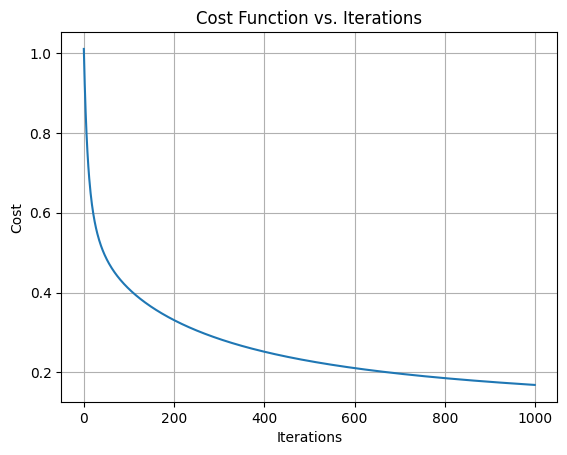

In [38]:
#training the model
#initializr the weights and biases
d= x_train.shape[1]#number of features
c= y_train.shape[1] #number of classes
w= np.random.randn(d,c) * 0.01 #small random weights
b= np.zeros(c) #bias initialized to 0
#set hyperparameters
alpha = 0.1 #learning rate
n_iter = 1000 #number of iterations
#train the model using gradient descent
w_opt, b_opt, cost_history = gradient_descent_softmax(x_train, y_train, w, b, alpha, n_iter, show_cost =True)
#plot the cost history to visualize the covergence
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()


In [39]:
#implementing evaluation function
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
#evaluation function
def evaluate_classifier(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  #compute precision, recall, and f1-score
  precision = precision_score(y_true, y_pred, average='weighted')
  recall = recall_score(y_true, y_pred, average='weighted')
  f1 = f1_score(y_true, y_pred, average='weighted')
  return cm, precision, recall, f1


In [41]:
#final result
#predict on the test set
y_pred_test = predict_softmax(x_test, w_opt, b_opt)
#evaluate accuracy
y_test_labels = np.argmax(y_test, axis =1) #true labels in numeric form
#evaluate the model
cm, precision, recall, f1 = evaluate_classifier(y_test_labels, y_pred_test)
#print the evaluation metrics
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Precision: 0.97
Recall: 0.97
F1-Score: 0.97
